In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from matplotlib import pyplot as plt
import seaborn as sns

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.codon import CodonDataset
from peint.models.modules.peint_module import PEINTModule
from peint.models.nets.peint import PEINT, ESMCodonEncoder, PEINTGenerator

from evo.sequence import get_mutant
from evo.dms import get_site_by_site_consensus
from evo.dataset import ComplexCherriesDataset
from evo.tokenization import CodonVocab

from tqdm import tqdm
tqdm.pandas()

In [18]:
# Load trained joint model from checkpoint
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/peint/logs/train/runs/2025-10-20_02-46-17/checkpoints")
ckpt_path = ckpt_dir / "last.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# create a fresh peint model with the same hyperparameters as the training run
vocab = CodonVocab.from_codons()
esm_encoder = ESMCodonEncoder.from_pretrained(
    codon_vocab=vocab,
    codon_embed_dim=384,
)
net = PEINT(
    enc_model=esm_encoder,
    evo_vocab=vocab,
    embed_dim=1024,
    num_heads=16,
    num_chains=2,
    num_encoder_layers=3,
    num_decoder_layers=3,
    max_len=1022,
    dropout_p=0.0,
    use_chain_embedding=True,
    use_attention_bias=True,
    causal_decoder=True,
)
module = PEINTModule.load_from_checkpoint(ckpt_path, net=net, map_location=device, strict=False)
module.net.in_embedding.codon_embedding.weight = module.net.enc_model.codon_embedding.weight
module = module.eval()

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.
/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/core/saving.py:191: Found keys that are in the model state dict but not in the checkpoint: ['net.enc_model.codon_to_aa_mapping', 'net.in_embedding.codon_embedding.weight']


In [19]:
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, mask_prob=0.0, datapath=None):
    if datapath is None:
        datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
        with open(datafile.name, "w") as f:
            f.write("{0} transitions\n".format(len(transitions)))
            f.write("\n".join(transitions))
        datapath = datafile.name

    dataset = CodonDataset(
        dataset=ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1),
        vocab=vocab,
        mask_prob=mask_prob,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
        permute_chain_order=False,
        embed_x_per_chain=True,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, module, n_batches = 100):
    # run inference on the dataloader
    lls, bls, ppl = [], [], []
    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch
        yt_mask = y_tgt != vocab.pad_idx  # actual values

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            outputs = module.net(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids, use_cache=False)
            x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.transpose(-1, -2)
        nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")

        ll = -nll * yt_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())

        bls.append(ts.detach().cpu().numpy())
        nll_mean = (nll * yt_mask.float()).sum(dim=-1) / yt_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks):
    tokens = []
    for tok in toks:
        if tok == vocab.bos_idx:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)    

In [20]:
# load the test dataset
# datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/nt/d4.txt")
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/extra/edges_joint/nt/dx.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)

In [ ]:
# infer log likelihoods at the codon level
lls, bls, ppl = infer_log_likelihoods(dataloader, module, n_batches=-1)

In [21]:
# infer log likelihoods at the amino acid level

n_batches = -1
lls, bls, ppl = [], [], []

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch

    # get one-hot target amino acids instead of codons
    # esm_encoder.codon_to_aa_mapping is a tensor mapping each codon to its corresponding amino acid index in the aa vocab
    y_aa_tgt = esm_encoder.codon_to_aa_mapping[y_tgt]
    yt_mask = y_aa_tgt != esm_encoder.aa_vocab.pad_idx  # actual values

    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        outputs = module.net(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids, use_cache=False)
        x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

    # logits are at the codon vocab level (bs, seq_len, len(codon_vocab))
    # i want to gather the logits (sum) over codons that map to the same amino acid to obtain a tensor of shape (bs, seq_len, len(esm_encoder.aa_vocab))
    y_logits_aa = torch.zeros(y_logits.size(0), y_logits.size(1), len(esm_encoder.aa_vocab), device=y_logits.device)
    for aa_idx in range(len(esm_encoder.aa_vocab)):
        codon_indices = (esm_encoder.codon_to_aa_mapping == aa_idx).nonzero(as_tuple=True)[0]
        y_logits_aa[:, :, aa_idx] = y_logits[:, :, codon_indices].logsumexp(dim=-1)

    y_logits = y_logits_aa - torch.logsumexp(y_logits_aa, dim=-1, keepdim=True)
    y_logits = y_logits.transpose(-1, -2)
    nll = F.cross_entropy(y_logits, y_aa_tgt, ignore_index=vocab.pad_idx, reduction="none")
    ll = -nll * yt_mask.float()
    ll = ll.sum(dim=-1)
    lls.append(ll.detach().cpu().numpy())

    bls.append(ts.detach().cpu().numpy())
    nll_mean = (nll * yt_mask.float()).sum(dim=-1) / yt_mask.float().sum(dim=-1)
    ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

    n_batches -= 1
    if n_batches == 0:
        break

lls = np.concatenate(lls)
bls = np.concatenate(bls)
ppl = np.concatenate(ppl)

Inference: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1180/1180 [02:32<00:00,  7.76it/s]


In [22]:
print('test perplexity: ', np.mean(ppl))

# save branch, lls, and ppls to a dataframe
df = pd.DataFrame({
    "branch": bls[:,0],
    "log_likelihood": lls,
    "perplexity": ppl,
})

df.to_csv("results/inf_eval/codon_model_aa_vocab_dx.csv", index=False)

test perplexity:  1.1747859


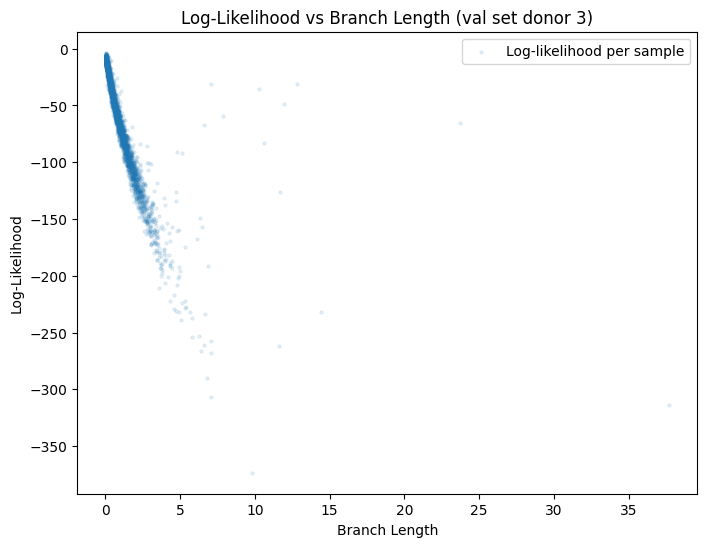

In [20]:
# plot the binned likelihoods according to the branch length
df = pd.DataFrame({'ll': lls, 'branch_length': bls[:, 0], 'ppl': ppl})
df["bl_bin"] = df["branch_length"] // df["branch_length"].quantile(.15).astype(float)
binned_df = df.groupby("bl_bin").mean()

fig, ax = plt.subplots(figsize=(8, 6))
# ax.scatter(binned_df.branch_length, binned_df.ll, label="Binned log-likelihood", s=10)
ax.scatter(df.branch_length, df.ll, alpha=0.1, label="Log-likelihood per sample", s=5)

ax.set_xlabel("Branch Length")
ax.set_ylabel("Log-Likelihood")
ax.set_title("Log-Likelihood vs Branch Length (val set donor 3)")
ax.legend()
plt.show()

### Validate sampling from the codon model

In [ ]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/nt/d4.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)

# load the generator from the peint model
generator = PEINTGenerator.from_peint(module.net).to(device)

In [12]:
# for each transition in the test set, sample a child sequence using the model and compute its hamming distance + codon usage compared to the true child sequence
real_parent_hv_seqs, real_parent_lt_seqs = [], []
real_child_hv_seqs, real_child_lt_seqs = [], []
sim_child_hv_seqs, sim_child_lt_seqs = [], []
branch_lengths = []
n_batches = 20

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch

    # get heavy chain lengths
    x_lens = (x_sizes[:,0]-1)*3
    y_lens = (y_sizes[:,0]-1)*3

    # decode the true child sequence using the vocab
    true_parent_seqs = [decode_sequence_from_toks(x_src[i].cpu().numpy()) for i in range(x_src.size(0))]
    true_child_seqs = [decode_sequence_from_toks(y_tgt[i].cpu().numpy()) for i in range(y_tgt.size(0))]
    true_hv_pa_seqs, true_lt_pa_seqs = zip(*[(seq[:hl], seq[hl:]) for seq, hl in zip(true_parent_seqs, x_lens)])
    true_hv_ch_seqs, true_lt_ch_seqs = zip(*[(seq[:hl], seq[hl:]) for seq, hl in zip(true_child_seqs, y_lens)])
    assert all([len(tc) == (ys.sum().item()) * 3 for tc, ys in zip(true_child_seqs, y_sizes)])

    # sample a child sequence using the model
    y_sizes[:,1] += 1
    y_decoded = generator.dec_generate(ts=ts, xs=x_src, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
    sim_child_seqs = [decode_sequence_from_toks(y_decoded[i].cpu().numpy()) for i in range(y_decoded.size(0))]
    sim_hv_seqs, sim_lt_seqs = zip(*[(seq[:hl], seq[hl:]) for seq, hl in zip(sim_child_seqs, y_lens)])
    assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_child_seqs)])

    real_parent_hv_seqs.extend(true_hv_pa_seqs)
    real_parent_lt_seqs.extend(true_lt_pa_seqs)
    real_child_hv_seqs.extend(true_hv_ch_seqs)
    real_child_lt_seqs.extend(true_lt_ch_seqs)
    sim_child_hv_seqs.extend(sim_hv_seqs)
    sim_child_lt_seqs.extend(sim_lt_seqs)
    branch_lengths.extend(ts[:,0].cpu().numpy())

    n_batches -= 1
    if n_batches == 0:
        break

Inference:   1%|█▋                                                                                                                                                                                 | 19/1968 [01:37<2:46:45,  5.13s/it]


In [14]:
assert len(true_parent_seqs[0]) == len(true_hv_pa_seqs[0]) + len(true_lt_pa_seqs[0])
assert len(true_child_seqs[0]) == len(true_hv_ch_seqs[0]) + len(true_lt_ch_seqs[0])
assert len(sim_child_seqs[0]) == len(sim_hv_seqs[0]) + len(sim_lt_seqs[0])
assert len(true_parent_seqs[0]) == len(true_child_seqs[0]) == len(sim_child_seqs[0])

In [29]:
# translate the sequences to amino acid sequences
from Bio.Seq import Seq

def translate_sequence(dna_seq):
    seq_obj = Seq(dna_seq)
    return str(seq_obj.translate())

real_hv_parent_aa_seqs = [translate_sequence(seq) for seq in real_parent_hv_seqs]
real_lt_parent_aa_seqs = [translate_sequence(seq) for seq in real_parent_lt_seqs]
real_hv_aa_seqs = [translate_sequence(seq) for seq in real_child_hv_seqs]
sim_hv_aa_seqs = [translate_sequence(seq) for seq in sim_child_hv_seqs]
real_lt_aa_seqs = [translate_sequence(seq) for seq in real_child_lt_seqs]
sim_lt_aa_seqs = [translate_sequence(seq) for seq in sim_child_lt_seqs]

In [30]:
# calculate hamming distances between corresponding real and simulated sequences
def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

hv_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_hv_aa_seqs, sim_hv_aa_seqs)]
lt_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_lt_aa_seqs, sim_lt_aa_seqs)]

hv_aa_hamming_dists_to_parent = [compute_hamming_distance(p, s) for p, s in zip(real_hv_parent_aa_seqs, sim_hv_aa_seqs)]
lt_aa_hamming_dists_to_parent = [compute_hamming_distance(p, s) for p, s in zip(real_lt_parent_aa_seqs, sim_lt_aa_seqs)]

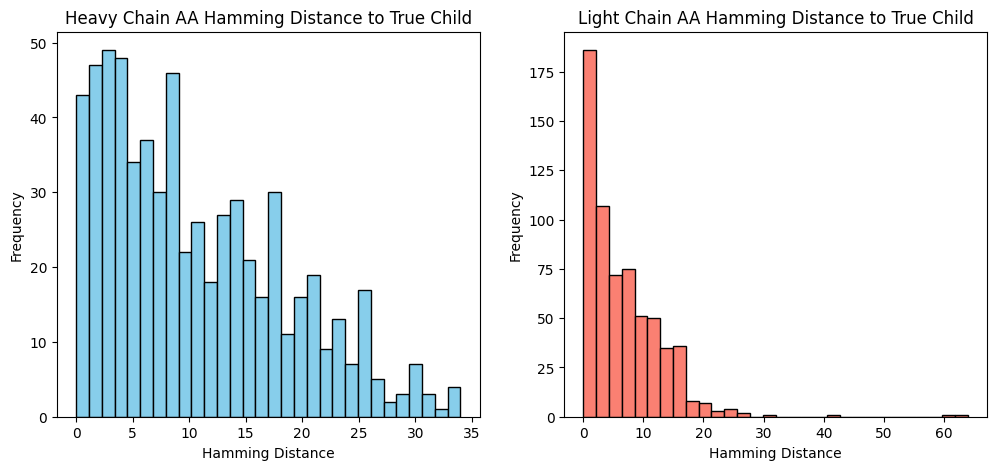

In [19]:
# plot a histogram of the hamming distances for heavy and light chains on the amino acid level (side by side)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(hv_aa_hamming_dists, bins=30, color='skyblue', edgecolor='black')
ax[0].set_title('Heavy Chain AA Hamming Distance to True Child')
ax[0].set_xlabel('Hamming Distance')
ax[0].set_ylabel('Frequency') 
ax[1].hist(lt_aa_hamming_dists, bins=30, color='salmon', edgecolor='black')
ax[1].set_title('Light Chain AA Hamming Distance to True Child')
ax[1].set_xlabel('Hamming Distance')
ax[1].set_ylabel('Frequency')
plt.show()

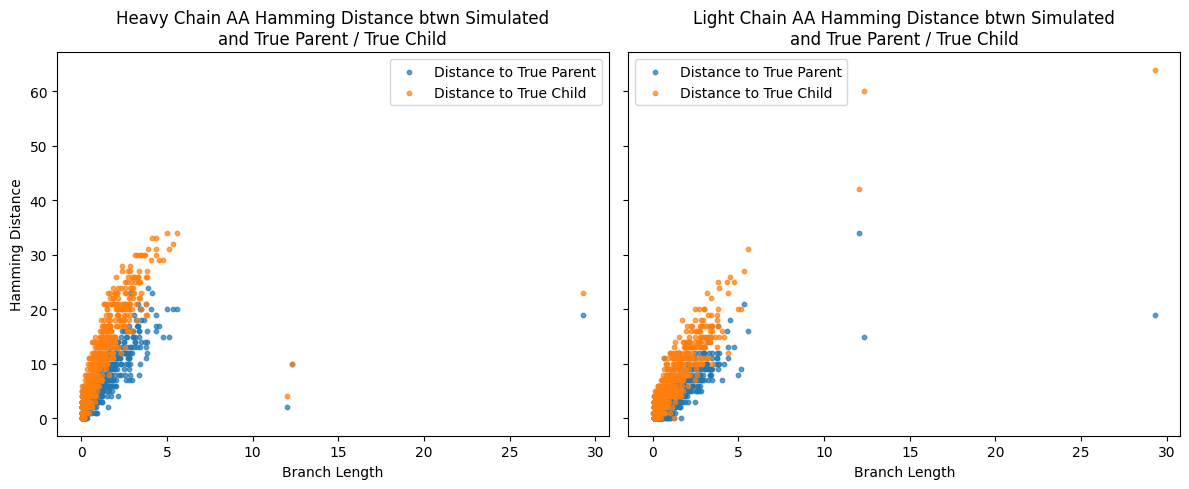

In [35]:
import numpy as np

# plot branch length vs hamming distance to parent and to true child (heavy & light)

bl = np.array(branch_lengths)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Heavy chain: distance to parent (blue) and to true child (orange)
ax[0].scatter(bl, hv_aa_hamming_dists_to_parent, color='C0', s=10, alpha=0.7, label='Distance to True Parent')
ax[0].scatter(bl, hv_aa_hamming_dists, color='C1', s=10, alpha=0.7, label='Distance to True Child')
ax[0].set_title('Heavy Chain AA Hamming Distance btwn Simulated\nand True Parent / True Child')
ax[0].set_xlabel('Branch Length')
ax[0].set_ylabel('Hamming Distance')
ax[0].legend()

# Light chain: distance to parent (blue) and to true child (orange)
ax[1].scatter(bl, lt_aa_hamming_dists_to_parent, color='C0', s=10, alpha=0.7, label='Distance to True Parent')
ax[1].scatter(bl, lt_aa_hamming_dists, color='C1', s=10, alpha=0.7, label='Distance to True Child')
ax[1].set_title('Light Chain AA Hamming Distance btwn Simulated\nand True Parent / True Child')
ax[1].set_xlabel('Branch Length')
ax[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# calculate codon usage frequencies for each set of sequences
from Bio.Seq import Seq
from collections import OrderedDict, Counter
from evo.sequence import HUMAN_CODON_USAGE

def compute_codon_usage_counts(sequence: str) -> dict:
    codon_counts = Counter()
    for i in range(0, len(sequence) - 2, 3):
        codon = sequence[i:i+3]
        if codon in HUMAN_CODON_USAGE:
            codon_counts[codon] += 1
    return codon_counts

def compute_aa_usage_counts(sequence: str) -> dict:
    aa_counts = Counter()
    for aa in sequence:
        aa_counts[aa] += 1
    return aa_counts

In [21]:
real_hv_codon_counts = [compute_codon_usage_counts(seq) for seq in real_child_hv_seqs]
real_hv_codon_counts = sum(real_hv_codon_counts, Counter())

sim_hv_codon_counts = [compute_codon_usage_counts(seq) for seq in sim_child_hv_seqs]
sim_hv_codon_counts = sum(sim_hv_codon_counts, Counter())

real_lt_codon_counts = [compute_codon_usage_counts(seq) for seq in real_child_lt_seqs]
real_lt_codon_counts = sum(real_lt_codon_counts, Counter())

sim_lt_codon_counts = [compute_codon_usage_counts(seq) for seq in sim_child_lt_seqs]
sim_lt_codon_counts = sum(sim_lt_codon_counts, Counter())

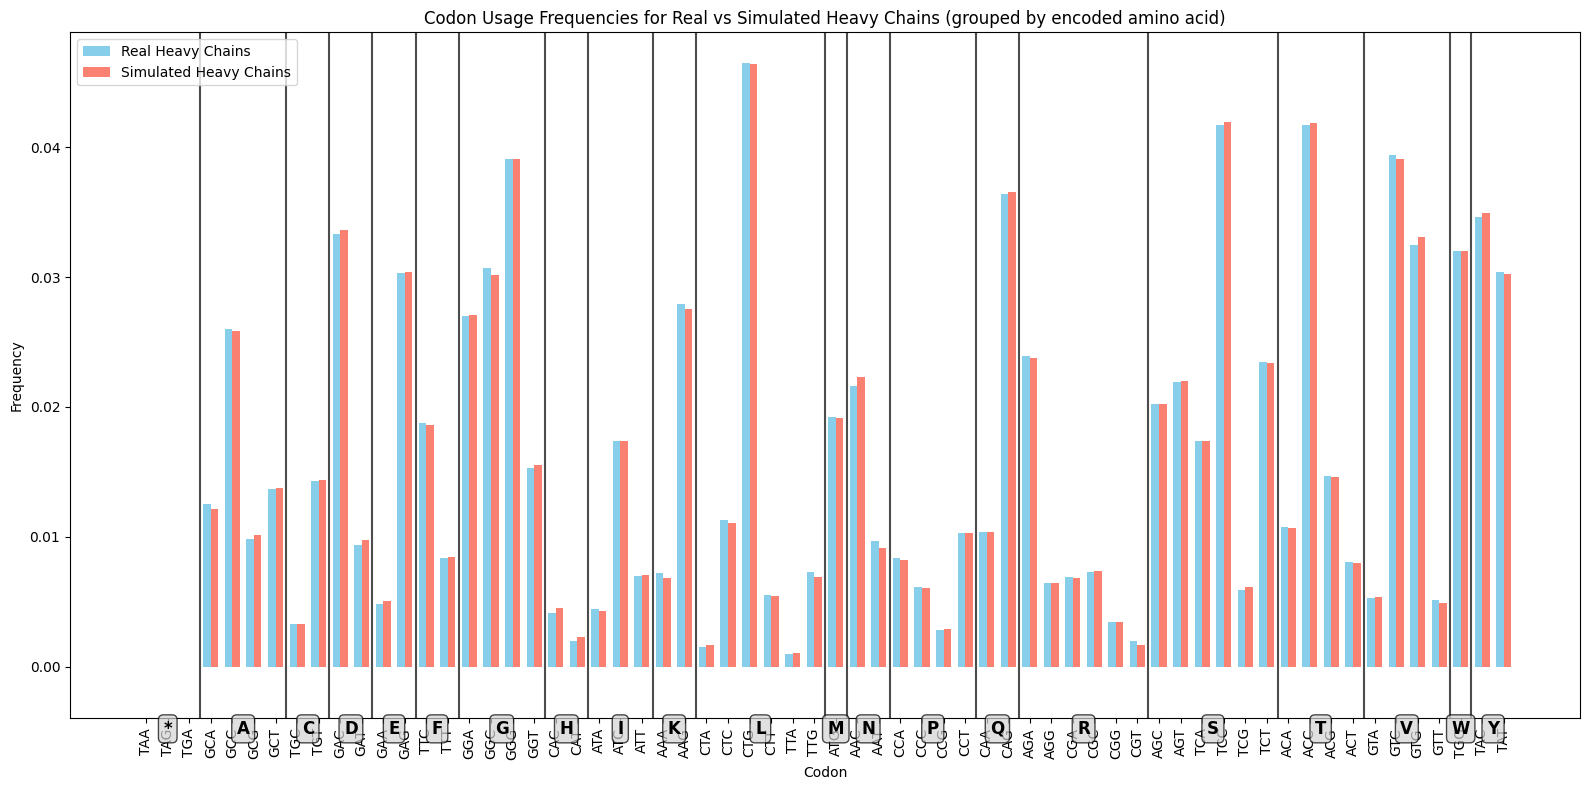

In [22]:
# plot the codon usage frequences for heavy chain
codons = sorted([c for c in HUMAN_CODON_USAGE.keys() if len(c) == 3 and set(c).issubset({'A', 'T', 'G', 'C'})])

# Create proper codon to amino acid mapping
codon_to_aa = {}
for c in codons:
    try:
        aa = str(Seq(c).translate())
        codon_to_aa[c] = aa
    except:
        continue  # Skip invalid codons

# Filter codons to only those with valid translations
valid_codons = [c for c in codons if c in codon_to_aa]

# **KEY FIX**: Sort codons by amino acid first, then by codon
# This ensures all codons for the same AA are grouped together
valid_codons = sorted(valid_codons, key=lambda c: (codon_to_aa[c], c))

# Now get frequencies for the properly sorted codons
heavy_real_freqs = [real_hv_codon_counts.get(codon, 0) / sum(real_hv_codon_counts.values()) for codon in valid_codons]
heavy_sim_freqs = [sim_hv_codon_counts.get(codon, 0) / sum(sim_hv_codon_counts.values()) for codon in valid_codons]

# Build ordered groups by amino acid
aa_groups = OrderedDict()
for i, c in enumerate(valid_codons):
    aa = codon_to_aa[c]
    aa_groups.setdefault(aa, []).append((i, c))

# Prepare plot
x = np.arange(len(valid_codons))
fig, ax = plt.subplots(figsize=(16, 8))
width = 0.35  # width of the bars
ax.bar(x - width/2, heavy_real_freqs, width, label='Real Heavy Chains', color='skyblue')
ax.bar(x + width/2, heavy_sim_freqs, width, label='Simulated Heavy Chains', color='salmon')

# Set ticks and codon labels
ax.set_xticks(x)
ax.set_xticklabels(valid_codons, rotation=90)
ax.set_xlabel('Codon')
ax.set_ylabel('Frequency')
ax.set_title('Codon Usage Frequencies for Real vs Simulated Heavy Chains (grouped by encoded amino acid)')

# Draw group separators and add amino-acid labels
for aa, items in aa_groups.items():
    indices = [idx for idx, _ in items]
    left = min(indices)
    right = max(indices)
    center = (left + right) / 2.0
    
    # Vertical separator at the right edge of the group (except after last group)
    if right < len(valid_codons) - 1:
        ax.axvline(right + 0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    
    # Place amino-acid labels below the x-axis at group centers
    ax.text(center, -0.002, aa, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))

# Improve layout
ax.set_ylim(bottom=-0.004)
plt.subplots_adjust(bottom=0.15)
ax.legend()
plt.tight_layout()
plt.show()

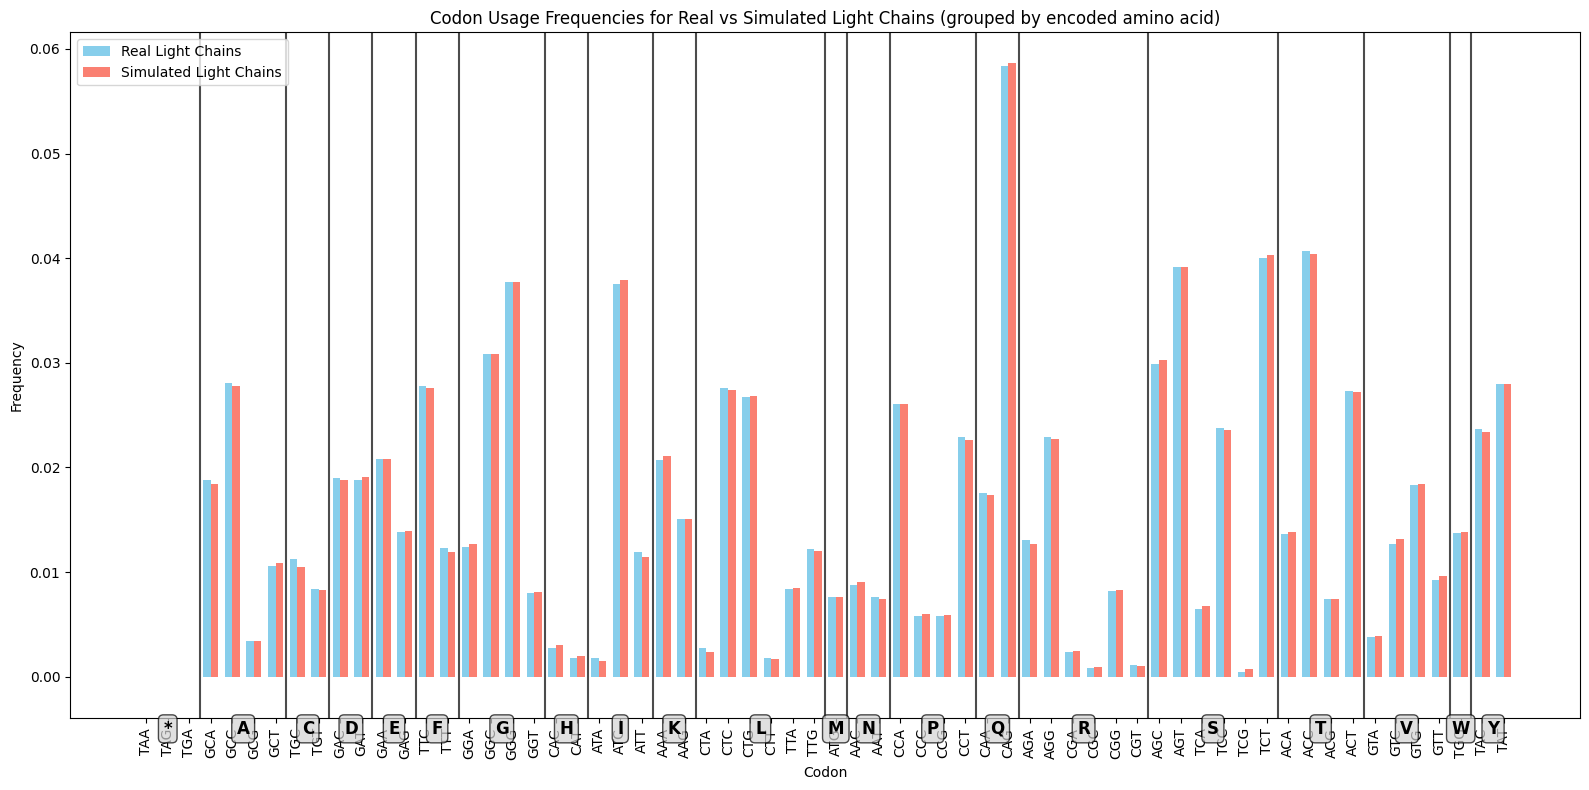

In [23]:
# plot the codon usage frequences for light chain
codons = sorted([c for c in HUMAN_CODON_USAGE.keys() if len(c) == 3 and set(c).issubset({'A', 'T', 'G', 'C'})])

# Create proper codon to amino acid mapping
codon_to_aa = {}
for c in codons:
    try:
        aa = str(Seq(c).translate())
        codon_to_aa[c] = aa
    except:
        continue  # Skip invalid codons

# Filter codons to only those with valid translations
valid_codons = [c for c in codons if c in codon_to_aa]

# **KEY FIX**: Sort codons by amino acid first, then by codon
# This ensures all codons for the same AA are grouped together
valid_codons = sorted(valid_codons, key=lambda c: (codon_to_aa[c], c))

# Now get frequencies for the properly sorted codons
light_real_freqs = [real_lt_codon_counts.get(codon, 0) / sum(real_lt_codon_counts.values()) for codon in valid_codons]
light_sim_freqs = [sim_lt_codon_counts.get(codon, 0) / sum(sim_lt_codon_counts.values()) for codon in valid_codons]

# Build ordered groups by amino acid
aa_groups = OrderedDict()
for i, c in enumerate(valid_codons):
    aa = codon_to_aa[c]
    aa_groups.setdefault(aa, []).append((i, c))

# Prepare plot
x = np.arange(len(valid_codons))
fig, ax = plt.subplots(figsize=(16, 8))
width = 0.35  # width of the bars
ax.bar(x - width/2, light_real_freqs, width, label='Real Light Chains', color='skyblue')
ax.bar(x + width/2, light_sim_freqs, width, label='Simulated Light Chains', color='salmon')

# Set ticks and codon labels
ax.set_xticks(x)
ax.set_xticklabels(valid_codons, rotation=90)
ax.set_xlabel('Codon')
ax.set_ylabel('Frequency')
ax.set_title('Codon Usage Frequencies for Real vs Simulated Light Chains (grouped by encoded amino acid)')

# Draw group separators and add amino-acid labels
for aa, items in aa_groups.items():
    indices = [idx for idx, _ in items]
    left = min(indices)
    right = max(indices)
    center = (left + right) / 2.0
    
    # Vertical separator at the right edge of the group (except after last group)
    if right < len(valid_codons) - 1:
        ax.axvline(right + 0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    
    # Place amino-acid labels below the x-axis at group centers
    ax.text(center, -0.002, aa, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))

# Improve layout
ax.set_ylim(bottom=-0.004)
plt.subplots_adjust(bottom=0.15)
ax.legend()
plt.tight_layout()
plt.show()

### Calculate log likelihoods of Koenig DMS data

In [67]:
# Infer ppl for the koenig binding dataset
df = pd.read_csv("data/Koenig2017_g6_er.csv")

heavy_wt = get_site_by_site_consensus(df, "heavy")
light_wt = get_site_by_site_consensus(df, "light")
print(len(heavy_wt), len(light_wt), len(heavy_wt) + len(light_wt))

df['heavy_mut'] = df['heavy'].apply(lambda x: get_mutant(x, heavy_wt))
df['light_mut'] = df['light'].apply(lambda x: get_mutant(x, light_wt))
df['mut'] = df['heavy_mut'] + df['light_mut']
df.set_index('mut', inplace=True)

print(df.shape)
df.head()

120 108 228
(4275, 5)


,heavy,light,fitness,heavy_mut,light_mut
mut,,,,,
V1A,EAQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.819679,V1A,
V1C,ECQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.328397,V1C,
V1D,EDQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.585834,V1D,
V1E,EEQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.806183,V1E,
V1F,EFQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.452152,V1F,


In [ ]:
from evo.antibody import KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ
heavy_wt = KOENIG_IGH_CON_SEQ
light_wt = KOENIG_IGK_CON_SEQ
codon_table = CodonVocab.GENETIC_CODE

EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS


In [73]:
def replace_with_codons(wt_nt_sequence: str, mut: str, offset: int = 0):
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = [k for k,v in codon_table.items() if v == new_aa]
    nt_pos = (pos - offset) * 3
    new_sequences = []
    for codon in codons:
        new_seq = wt_nt_sequence[:nt_pos] + codon + wt_nt_sequence[nt_pos+3:]
        new_sequences.append(new_seq)
    return new_sequences

In [ ]:
results = []
muts = []

for i, row in tqdm(df.iterrows()):
    did_heavy_change = row['heavy_mut'] != ''
    mut = row['heavy_mut'] if did_heavy_change else row['light_mut']

    if did_heavy_change:
        heavy_nt_muts = replace_with_codons(heavy_wt, mut, offset=0)
        light_nt_muts = [light_wt] * len(heavy_nt_muts)
        assert Seq(heavy_nt_muts[0]).translate() == row['heavy']
    else:
        light_nt_muts = replace_with_codons(light_wt, mut, offset=0)
        heavy_nt_muts = [heavy_wt] * len(light_nt_muts)
        assert Seq(light_nt_muts[0]).translate() == row['light']

    transitions = [f"{heavy_wt}.{light_wt} {heavy_mt}.{light_mt} 7" for heavy_mt, light_mt in zip(heavy_nt_muts, light_nt_muts)]
    dataloader = dataloader_from_transitions(transitions, batch_size=32)
    lls, bls, ppl = infer_log_likelihoods(dataloader, module, n_batches=100)
    
    muts.append(mut)
    results.append(lls)

Inference: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 14.83it/s]


In [96]:
np.log(np.exp(results[0]).sum())

-102.18032

In [107]:
from scipy.special import logsumexp

for mut, result in zip(muts, results):
    total_log_prob = logsumexp(result)
    # total_log_prob = np.mean(result)

    if np.isnan(total_log_prob) or total_log_prob == -np.inf:
        print(result)
        break
    
    df.at[mut, 'll'] = total_log_prob
    df.at[mut, 'ppl'] = np.exp(-total_log_prob / (len(heavy_wt) + len(light_wt)))

In [104]:
df.to_csv("/h/290/stephenzlu/peint/data/Koenig2017_codon_model_t=7.csv", index=False)

In [108]:
# calculate the pearson correlation between the ppl column and the log 'fitness' column
from scipy.stats import pearsonr
fitness = df['fitness'].values
log_fitness = np.log(fitness + 1e-8)
ppl = df['ppl'].values
correlation, p_value = pearsonr(ppl, log_fitness)
print(f"Pearson correlation between ppl and log fitness: {correlation:.4f} (p-value: {p_value:.4e})")

Pearson correlation between ppl and log fitness: -0.5609 (p-value: 0.0000e+00)
